# BosonSR Binary Transition: Basic Analysis

This notebook runs a compact smoke-analysis of the non-CBC `BosonSR_binary` waveform. The GW wrapper loads the binary-transition implementation from `../henry/julia_wf/functions.jl`.

In [1]:
using Pkg

candidate_dirs = unique([
    abspath(@__DIR__),
    abspath(pwd()),
    joinpath(abspath(@__DIR__), "GW_free_params.jl"),
    joinpath(abspath(pwd()), "GW_free_params.jl"),
])

project_dir_idx = findfirst(dir -> isfile(joinpath(dir, "Project.toml")) && isfile(joinpath(dir, "src", "GW.jl")), candidate_dirs)
project_dir_idx === nothing && error("Could not find GW_free_params.jl project directory from pwd=$(pwd()) and @__DIR__=$(@__DIR__)")
project_dir = candidate_dirs[project_dir_idx]
repo_dir = dirname(project_dir)

wrapper_source = joinpath(project_dir, "src", "waveforms", "bosonSR_binary_transition.jl")
binary_source = joinpath(repo_dir, "henry", "julia_wf", "functions.jl")
@assert isfile(wrapper_source) wrapper_source
@assert isfile(binary_source) binary_source

Pkg.activate(project_dir)
include(joinpath(project_dir, "src", "GW.jl"))
using .GW
using .GW: BosonSR_binary, Pol, Strain, SNR, FisherMatrix, CE1Id_coordinates, CE1Id, ETLS, ETLMR, _available_waveforms
using Plots

default(size=(850, 420), linewidth=2, grid=true)

println("GW project: ", project_dir)
println("GW wrapper: ", wrapper_source)
println("binary-transition implementation: ", binary_source)

  Activating 

GW project: /home/cherrytree/bosonSR_repo_/GW_free_params.jl

project at `~/bosonSR_repo_/GW_free_params.jl`



GW wrapper: /home/cherrytree/bosonSR_repo_/GW_free_params.jl/src/waveforms/bosonSR_binary_transition.jl
binary-transition implementation: /home/cherrytree/bosonSR_repo_/henry/julia_wf/functions.jl


## Waveform and Parameters

`dL` is in Gpc. The example uses a nearby source (`1e-6` Gpc = 1 kpc) and a black-hole mass that places the transition near 100 Hz. `Gamma_abs` is supplied in the natural-energy units expected by Henry's waveform.

In [2]:
model = GW.BosonSR_binary()

q = 1.0e-3
M_solar = 1.0e-3
alpha_sr = 0.21
Gamma_abs = 1.0e-14
intrinsic = (q, M_solar, alpha_sr, Gamma_abs)

dL = 1.0e-6
theta = 1.0
phi = 2.0
iota = 0.4
psi = 0.7
tcoal = 0.2
phiCoal = 0.0

f_center = GW.waveform._henry_central_frequency_Hz(model, q, M_solar, alpha_sr)
fmin = max(2.0, 0.7 * f_center)
fmax = 1.3 * f_center
f = collect(range(fmin, fmax, length=800))

println("available non-CBC model: ", GW._available_waveforms("BosonSR_binary"))
println("parameter names: ", GW.waveform._parameter_names(model))
println("central frequency [Hz]: ", f_center)
println("analysis band [Hz]: ", (first(f), last(f)))
println("Henry function module: ", GW.waveform.HenryBinaryTransition)

available non-CBC model: BosonSR_binary(1, -1, 2, 1, false, false)
parameter names: (:q, :M_solar, :alpha, :Gamma_abs, :dL, :theta, :phi, :iota, :psi, :tcoal, :phiCoal)
central frequency [Hz]: 104.45293833550052
analysis band [Hz]: (73.11705683485036, 135.78881983615068)
Henry function module: Main.GW.waveform.HenryBinaryTransition


## Source-Frame Polarizations

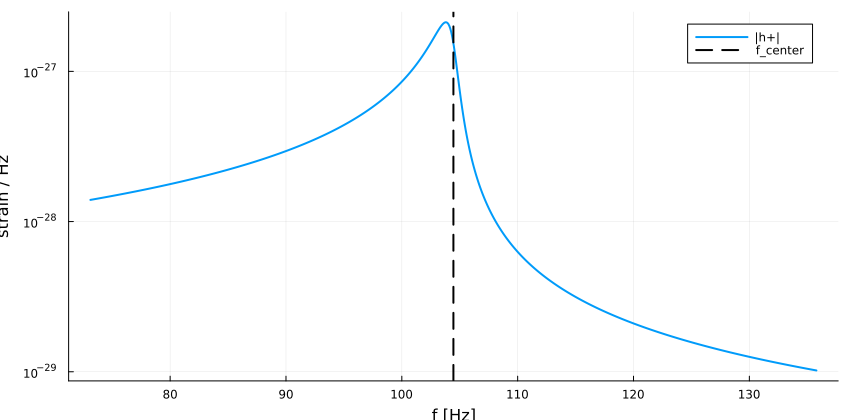

In [17]:
h_plus, h_cross = Pol(model, f, intrinsic, dL, iota)

plot(f, abs.(h_plus), label="|h+|", xlabel="f [Hz]", ylabel="strain / Hz", yscale=:log10)
#plot!(f, abs.(h_cross), label="|hx|")
vline!([f_center], label="f_center", linestyle=:dash, color=:black)

## Detector Strain

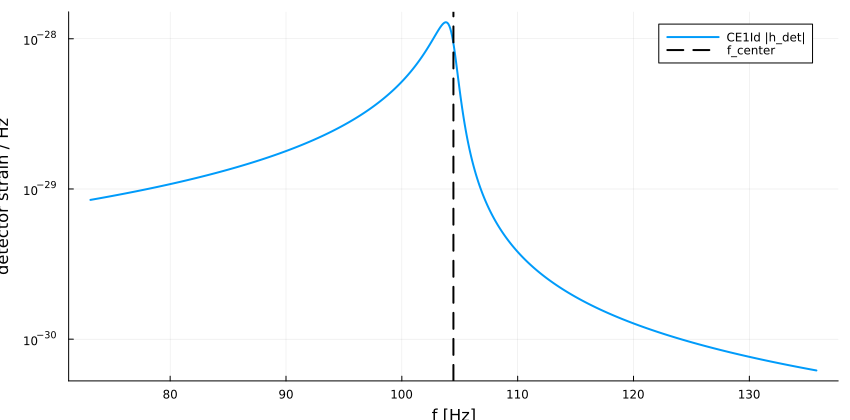

In [4]:
strain_ce = Strain(
    model,
    CE1Id_coordinates,
    f,
    intrinsic,
    dL,
    theta,
    phi,
    iota,
    psi,
    tcoal,
    phiCoal,
)

plot(f, abs.(strain_ce), label="CE1Id |h_det|", xlabel="f [Hz]", ylabel="detector strain / Hz", yscale=:log10)
vline!([f_center], label="f_center", linestyle=:dash, color=:black)

## SNR

In [5]:
network = [ETLS, ETLMR, CE1Id]

M_solar_range = 10.0 .^ range(-4, -2, length=10)
alpha_range = collect(range(0.15, 0.30, length=10))
snr_matrix = fill(NaN, length(M_solar_range), length(alpha_range));

In [6]:
for (i, M_solar_i) in enumerate(M_solar_range)
    for (j, alpha_j) in enumerate(alpha_range)
        intrinsic_ij = (q, M_solar_i, alpha_j, Gamma_abs)
        f_center_ij = GW.waveform._henry_central_frequency_Hz(model, q, M_solar_i, alpha_j)
        isfinite(f_center_ij) && f_center_ij > 0 || continue

        fmin_ij = max(2.0, 0.7 * f_center_ij)
        fmax_ij = 1.3 * f_center_ij
        fmax_ij > fmin_ij || continue

        try
            snr_matrix[i, j] = SNR(
                model, network, intrinsic_ij, dL, theta, phi, iota, psi, tcoal;
                fmin=fmin_ij, fmax=fmax_ij, res=80,
            )
        catch err
            @warn "SNR calculation failed" M_solar_i alpha_j exception=(err, catch_backtrace())
        end
    end
end

snr_matrix

10×10 Matrix{Float64}:
   3.58898e-31  1.05867e-22  3.63762e-17  …  0.000423115  4.37297e-5
   4.73723e-31  1.66877e-22  9.91183e-17     0.00155067   0.00131417
   4.80097e-31  2.32474e-22  1.63266e-16     0.00545089   0.00478052
   7.43667e-31  2.66249e-22  2.34181e-16     0.0191106    0.0168939
   8.90869e-31  3.24572e-22  2.89032e-16     0.0636762    0.0587886
   1.33248e-30  4.36385e-22  2.98736e-16  …  0.188564     0.191979
   7.87039e-31  6.21188e-22  4.55031e-16     0.449741     0.54412
   2.03351e-31  6.26826e-22  5.99304e-16     0.834368     1.21807
   3.41847e-32  1.95435e-22  7.764e-16       1.28523      2.14052
 NaN            4.23184e-23  3.03148e-16     1.7614       3.19138

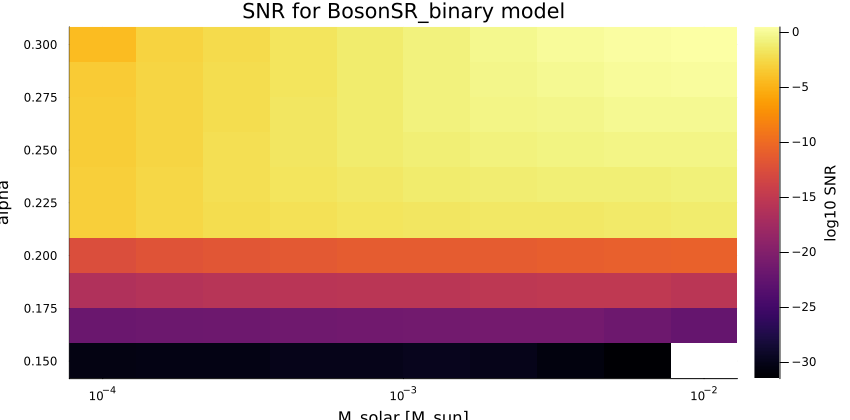

In [7]:
heatmap(
    M_solar_range, alpha_range, log10.(snr_matrix)';
    ylabel="alpha", xlabel="M_solar [M_sun]",
    title="SNR for BosonSR_binary model", colorbar_title="log10 SNR",
    xscale=:log10,
)

## Small Fisher Matrix

This is intentionally low resolution. Increase `res` after the smoke run is stable.

11×11 Matrix{Float64}:
  0.984277        80.649        …      -1.07954e-8   -9.84593e-21
 80.649         9460.19                 1.20657e-6    1.08078e-18
 -2.59366       -302.96                 6.72408e-8    2.40978e-20
  4.73557e10       2.7096e12       -71021.6           3.4523e-10
 36.5012       -4118.44                -0.00135909    9.01357e-18
  0.000381314     -0.0426182    …       0.0372766    -5.85591e-5
  0.000148448     -0.0165915            0.0100454    -1.57807e-5
  1.42606e-5      -0.00159386          -5.27932e-10  -6.48649e-24
 -0.000482387      0.0539147            1.78581e-8   -4.30944e-22
 -1.07954e-8       1.20657e-6           1.87169      -0.0029403
 -9.84593e-21      1.08078e-18  …      -0.0029403     4.62996e-6

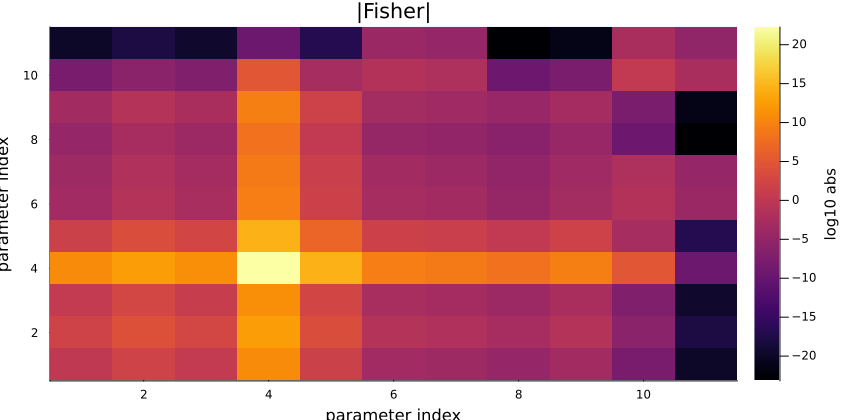

In [14]:
fisher = FisherMatrix(
    model, CE1Id, intrinsic, dL, theta, phi, iota, psi, tcoal, phiCoal;
    res=200, fmin=fmin, fmax=fmax, rho_thres=nothing,
)

display(fisher)
heatmap(log10.(abs.(fisher)), xlabel="parameter index", ylabel="parameter index", title="|Fisher|", colorbar_title="log10 abs")

## Median SNR over Extrinsic-Parameter Priors

For each point on the intrinsic grid, this section evaluates the network SNR for 20 common Monte Carlo draws from the catalog priors: `cos(theta), cos(iota) ~ Uniform(-1, 1)`, `phi, phiCoal ~ Uniform(0, 2pi)`, `psi ~ Uniform(0, pi)`, and `tcoal ~ Uniform(0, 1)` day. The plotted value is the median over those draws. `phiCoal` is sampled as part of the full extrinsic tuple but is absent from the SNR API because a constant phase does not change the SNR.

In [9]:
using Random, Statistics

n_extrinsic_samples = 20
prior_rng = MersenneTwister(20260715)
extrinsic_samples = [
    (
        theta=acos(2.0 * rand(prior_rng) - 1.0),
        phi=2.0 * pi * rand(prior_rng),
        iota=acos(2.0 * rand(prior_rng) - 1.0),
        psi=pi * rand(prior_rng),
        tcoal=rand(prior_rng),
        phiCoal=2.0 * pi * rand(prior_rng),
    )
    for _ in 1:n_extrinsic_samples
]

function network_snr_from_polabs(model, network, intrinsic, dL, sample, pol_abs; fmin, fmax, res)
    detector_snrs = [
        SNR(
            model, detector, intrinsic, dL, sample.theta, sample.phi, sample.iota, sample.psi, sample.tcoal;
            fmin=fmin, fmax=fmax, res=res, ampl_precomputation=pol_abs,
        )
        for detector in network
    ]
    return sqrt(sum(abs2, detector_snrs))
end

network_snr_from_polabs (generic function with 1 method)

In [10]:
median_snr_matrix = fill(NaN, length(M_solar_range), length(alpha_range))
prior_res = 80

for (i, M_solar_i) in enumerate(M_solar_range)
    for (j, alpha_j) in enumerate(alpha_range)
        intrinsic_ij = (q, M_solar_i, alpha_j, Gamma_abs)
        f_center_ij = GW.waveform._henry_central_frequency_Hz(model, q, M_solar_i, alpha_j)
        isfinite(f_center_ij) && f_center_ij > 0 || continue

        fmin_ij = max(2.0, 0.7 * f_center_ij)
        fmax_ij = 1.3 * f_center_ij
        fcut_ij = min(GW.waveform._fcut(model, intrinsic_ij...), fmax_ij)
        fcut_ij > fmin_ij || continue
        fgrid_ij = 10.0 .^ range(log10(fmin_ij), log10(fcut_ij), length=prior_res)

        h0_ij = GW.waveform._henry_plus_amplitude(model, fgrid_ij, q, M_solar_i, alpha_j, Gamma_abs, dL)
        sampled_snrs = Float64[]
        for sample in extrinsic_samples
            inclination_factor = 0.5 * (1.0 + cos(sample.iota)^2)
            pol_abs = [abs.(inclination_factor .* h0_ij), zeros(length(fgrid_ij))]
            try
                push!(sampled_snrs, network_snr_from_polabs(
                    model, network, intrinsic_ij, dL, sample, pol_abs;
                    fmin=fmin_ij, fmax=fmax_ij, res=prior_res,
                ))
            catch err
                @warn "Sampled SNR calculation failed" M_solar_i alpha_j exception=(err, catch_backtrace())
            end
        end

        finite_snrs = filter(isfinite, sampled_snrs)
        isempty(finite_snrs) || (median_snr_matrix[i, j] = median(finite_snrs))
    end
end

median_snr_matrix

10×10 Matrix{Float64}:
   2.8837e-31   8.0874e-23   2.95282e-17  …  0.000188606  1.94928e-5
   3.96374e-31  1.33106e-22  7.48301e-17     0.00134014   0.00059011
   5.41734e-31  1.89602e-22  1.29707e-16     0.00407577   0.00389913
   7.92611e-31  2.5055e-22   1.89581e-16     0.0152055    0.0131243
   8.90977e-31  3.696e-22    2.53248e-16     0.0505344    0.0467891
   8.43667e-31  4.81587e-22  3.60762e-16  …  0.143642     0.151333
   3.68423e-31  4.98832e-22  5.03499e-16     0.334896     0.41012
   9.06452e-32  3.18882e-22  5.13114e-16     0.640583     0.909761
   1.52381e-32  8.71164e-23  4.25585e-16     1.02685      1.66894
 NaN            1.88637e-23  1.37565e-16     1.44182      2.56263

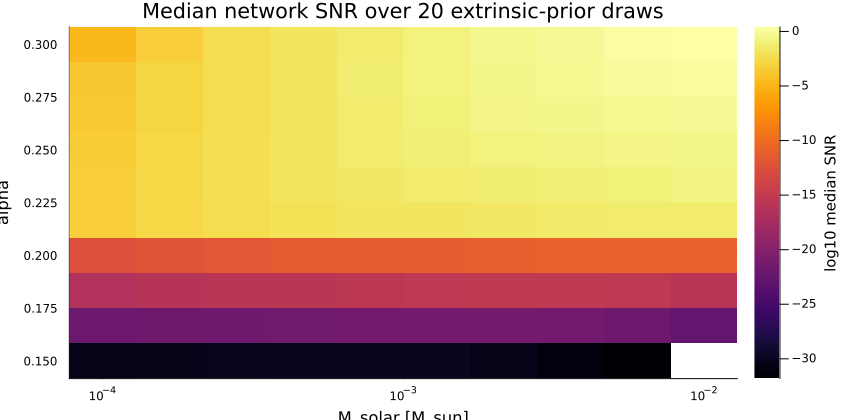

In [11]:
heatmap(
    M_solar_range, alpha_range, log10.(median_snr_matrix)';
    ylabel="alpha", xlabel="M_solar [M_sun]",
    title="Median network SNR over $(n_extrinsic_samples) extrinsic-prior draws",
    colorbar_title="log10 median SNR", xscale=:log10,
)